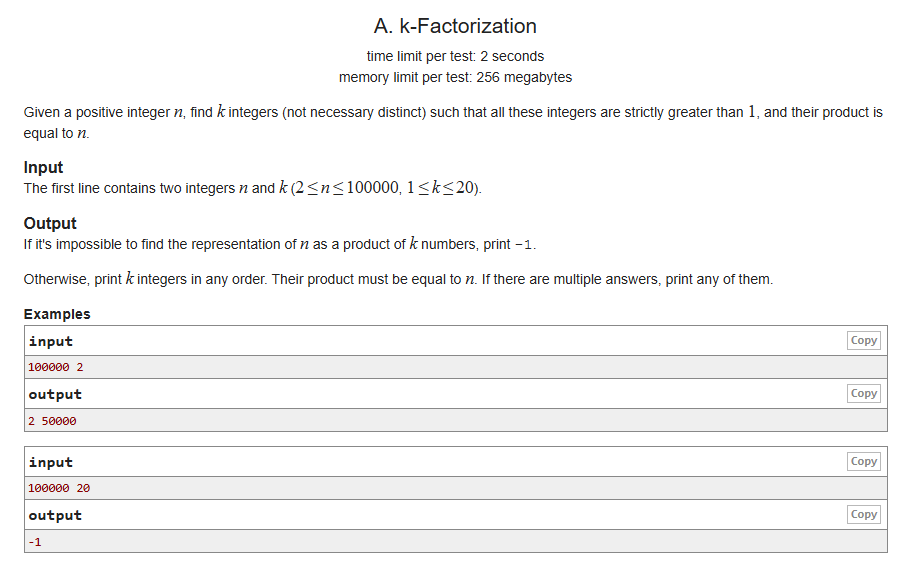
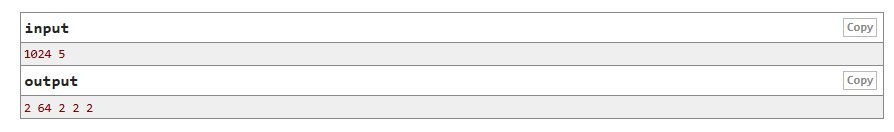

In [ ]:
# Notes approach

def Kfactorize(n, k, spf):
    ans = []

    while n > 1:
        ans.append(spf[n])
        n //= spf[n]

    n = len(ans)

    # print(ans)
    prod = 1

    if k > n:
        print(-1)
    else:
        for i in range(k - 1): # just print the first (k - 1) factors
            print(ans[i])
        for i in range(k - 1, n):# finally just add the product of the rest as the k-th factor
            prod *= ans[i]
    print(prod)


    # return ans


n, k = map(int, input().split())

spf = [i for i in range(n + 1)]

# Computing the SPF
i = 2
while i * i <= n:
    if spf[i] == i:
        j = i * i
        while j <= n:
            if spf[j] == j:
                spf[j] = i
            j += i
    i += 1

# print(spf)

Kfactorize(n, k, spf)

2
2
2
2
64


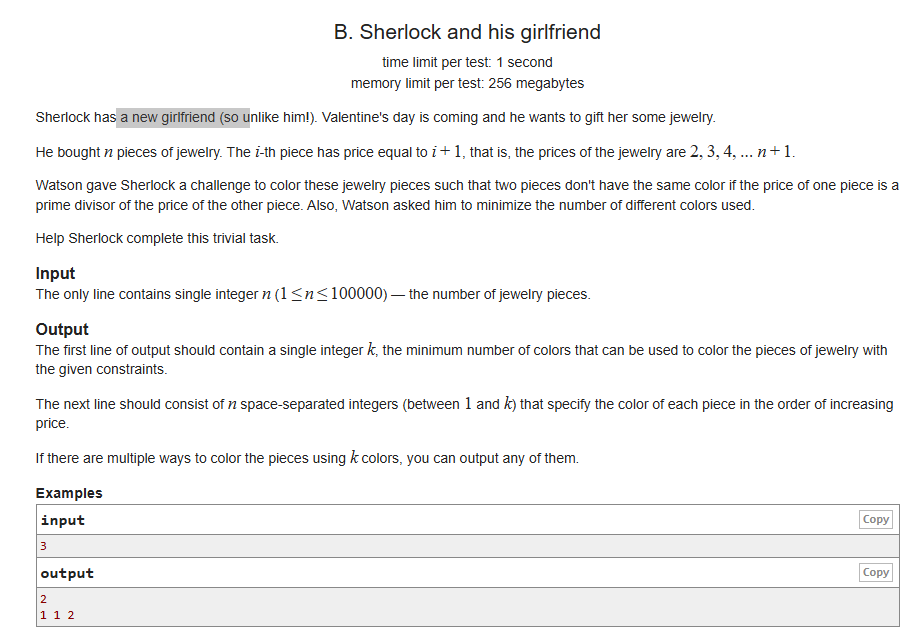
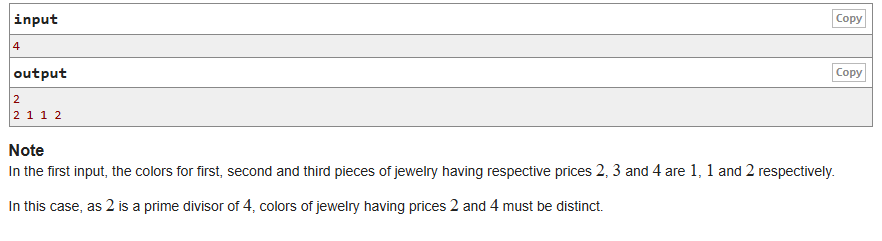

| Feature | Code 1 (Instance Method) | Code 2 (Class Variable) |
| :--- | :--- | :--- |
| **Trigger** | Called via `soln.sieve()` | Executed at Class Definition |
| **Frequency (1 instance)** | 1 time | 1 time |
| **Frequency (100 instances)** | **100 times** (Repeats work) | **1 time** (Shared result) |
| **Efficiency** | Low (if scaled) | **High** (Optimal) |

In [ ]:
# Code 1

class Solution:
    def sieve(self):
        n = int(input())
        mx = 100005
        self.spf = [True] * (mx)
        self.spf[0] = False
        self.spf[1] = False

        i = 2
        while i * i < mx:
            if self.spf[i]:
                j = i * i
                # print(i)
                while j < mx:
                    self.spf[j] = False
                    j += i
                    # print(j)
            i += 1
        self.solve(n)
        

    def solve(self, n):

        if n == 1:
            print(1)
            print(1)
        elif n == 2:
            print(1)
            print(1, 1, sep = ' ')
        else:
            print(2)
            for i in range(2, n + 2):
                if self.spf[i]:
                    print(2, end = ' ')
                else:
                    print(1, end = ' ')

soln = Solution()
soln.sieve()

AttributeError: 'Solution' object has no attribute 'spf'

In [ ]:
# Code 2
import sys

# Increase recursion depth just in case, though not needed for this iterative solution
sys.setrecursionlimit(2000)

class Solution:
    # Class-level variable to store sieve results. 
    # Computed only once when the class is defined or first accessed.
    MAX_N = 100005
    is_prime = [True] * MAX_N
    
    # Static block to run sieve exactly once
    is_prime[0] = False
    is_prime[1] = False
    
    for i in range(2, int(MAX_N**0.5) + 1):
        if is_prime[i]:
            for j in range(i * i, MAX_N, i):
                is_prime[j] = False

    def solve(self):
        # Read input
        try:
            line = sys.stdin.read().split()
            if not line:
                return
            n = int(line[0])
        except ValueError:
            return

        # Logic for minimum colors
        if n <= 2:
            print(1)
        else:
            print(2)

        # Assign colors: Primes -> 1, Composites -> 2
        # Range of jewelry prices is 2 to n+1
        colors = []
        for i in range(2, n + 2):
            if self.is_prime[i]:
                colors.append('1')
            else:
                colors.append('2')
        
        print(" ".join(colors))

if __name__ == '__main__':
    soln = Solution()
    soln.solve()   

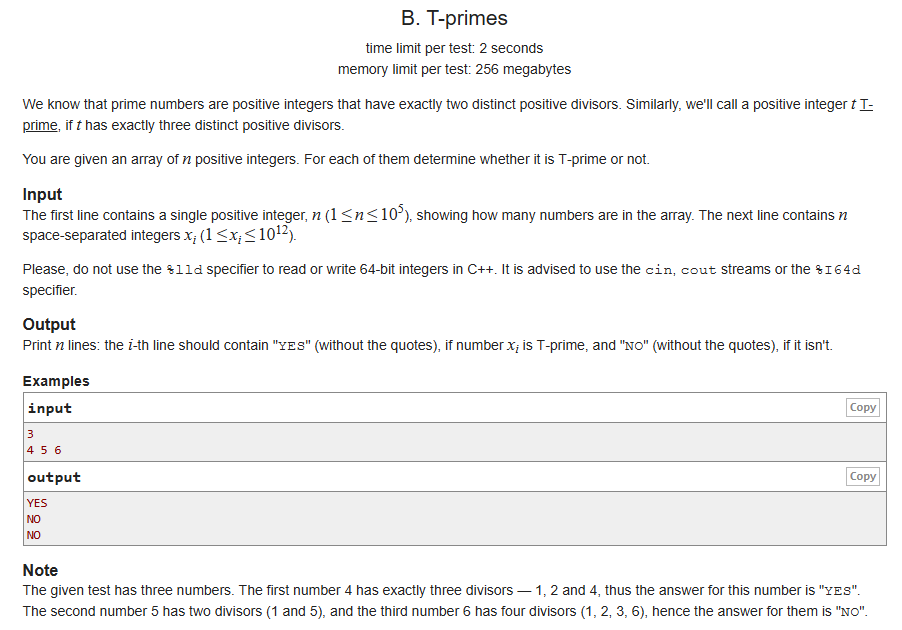

In [ ]:
# Note: can we use trivial division for this question?

# Let $N$ be the number of elements in the array and $X$ be the value of an element ($X \le 10^{12}$). 

# Trivial Division (Per Query):
# To check if a number $x$ is T-prime, you might try to count its divisors by iterating from $1$ to $\sqrt{x}$.
# Operations per query: $\approx \sqrt{10^{12}} = 10^6$.
# Total Operations: $N \times 10^6$.
# With $N = 10^5$ (standard constraint), total operations $\approx 10^{11}$.
# Result: Far exceeds the typical limit of $10^8$ operations per second. TLE. 



In [ ]:
# Your code attempts: spf = [i for i in range(1000000000005)].

# This tries to create a list with 1 trillion elements.

# Memory Calculation: A list of 1 trillion integers requires roughly 8 Terabytes (TB) 
# of RAM (assuming 8 bytes per pointer + object overhead).

# Result: Codeforces (and almost any computer) has a memory limit of 256 MB. 
# You will get a Memory Limit Exceeded (MLE) or crash instantly. 

class Solution:
    mx = 1000000000005
    spf = [i for i in range(mx)]

    for i in range(2, int(mx ** 0.5) + 1):
        for j in range(i * i, mx, i):
            if spf[j] == j:
                spf[j] = i
    

    def t_prime(self):

        n = int(input())
        arr = list(map(int, input().split()))

        for i in range(n):
            p = self.spf[arr[i]]
            if p * p == arr[i] and arr[i] != 1:
                print('YES')
            else:
                print('NO')

soln = Solution()
soln.t_prime()

KeyboardInterrupt: 

In [ ]:
import sys
import math

def solve():
    # Use fast I/O
    input = sys.stdin.read
    data = input().split()
    
    if not data:
        return

    n = int(data[0])
    # Convert only the needed part to integers
    queries = map(int, data[1:])
    
    # 1. Sieve up to 10^6 (sqrt of max input 10^12)
    LIMIT = 1000001
    is_prime = [True] * LIMIT
    is_prime[0] = is_prime[1] = False
    
    for i in range(2, int(math.isqrt(LIMIT)) + 1):
        if is_prime[i]:
            for j in range(i * i, LIMIT, i):
                is_prime[j] = False
    
    results = []
    
    # 2. Process queries
    for x in queries:
        if x < 4:
            results.append("NO")
            continue
        
        root = math.isqrt(x)
        
        # Check: Perfect Square AND Root is Prime
        if root * root == x and is_prime[root]:
            results.append("YES")
        else:
            results.append("NO")
            
    print('\n'.join(results))

if __name__ == '__main__':
    solve()   